In [46]:

import numpy as np
import matplotlib.pyplot as plt

In [47]:
import re
import numpy as np


def parse_cst_block_file(path):
    """Parse CST text export and return blocks grouped as blocks[n][ratio]."""
    blocks = {}
    current_n = None
    current_ratio = None
    current_x = []
    current_y = []

    with open(path, "r", encoding="utf-8") as f:
        for raw_line in f:
            line = raw_line.strip()
            if not line:
                continue

            if line.startswith("#Parameters"):
                if current_n is not None and current_ratio is not None and current_x:
                    if current_n not in blocks:
                        blocks[current_n] = {}
                    blocks[current_n][current_ratio] = {
                        "x": np.array(current_x, dtype=float),
                        "y": np.array(current_y, dtype=float),
                    }

                m_ratio = re.search(r"Ratio\s*=\s*([0-9]*\.?[0-9]+)", line)
                m_n = re.search(r"n\s*=\s*([0-9]*\.?[0-9]+)", line)

                if m_ratio is None or m_n is None:
                    current_n = None
                    current_ratio = None
                    current_x = []
                    current_y = []
                    continue

                current_ratio = float(m_ratio.group(1))
                current_n = int(round(float(m_n.group(1))))
                current_x = []
                current_y = []
                continue

            if line.startswith("#"):
                continue

            if current_n is None or current_ratio is None:
                continue

            parts = line.split()
            if len(parts) < 2:
                continue

            try:
                x_val = float(parts[0])
                y_val = float(parts[1])
            except ValueError:
                continue

            current_x.append(x_val)
            current_y.append(y_val)

    if current_n is not None and current_ratio is not None and current_x:
        if current_n not in blocks:
            blocks[current_n] = {}
        blocks[current_n][current_ratio] = {
            "x": np.array(current_x, dtype=float),
            "y": np.array(current_y, dtype=float),
        }

    return blocks

Valori di n disponibili: [1, 2, 3]
n=1 ratio=0.100  G=3.413456e-02  eta_E0=3.413456e-02  Emax=1.223394e+00  eta_Emax=2.790153e-02  phi=+3.1355 rad (+179.65 deg)L=1.000000e+00 um
n=1 ratio=0.200  G=2.464247e-02  eta_E0=2.464247e-02  Emax=1.144007e+00  eta_Emax=2.154048e-02  phi=-3.1379 rad (-179.79 deg)L=1.000000e+00 um
n=1 ratio=0.300  G=2.183641e-02  eta_E0=2.183641e-02  Emax=1.059628e+00  eta_Emax=2.060761e-02  phi=-3.1262 rad (-179.12 deg)L=1.000000e+00 um
n=1 ratio=0.400  G=2.013177e-02  eta_E0=2.013177e-02  Emax=9.825409e-01  eta_Emax=2.048950e-02  phi=-3.1131 rad (-178.37 deg)L=1.000000e+00 um
n=1 ratio=0.500  G=1.873206e-02  eta_E0=1.873206e-02  Emax=9.176876e-01  eta_Emax=2.041224e-02  phi=-3.0993 rad (-177.58 deg)L=1.000000e+00 um
n=1 ratio=0.600  G=1.767935e-02  eta_E0=1.767935e-02  Emax=8.666169e-01  eta_Emax=2.040042e-02  phi=-3.0850 rad (-176.76 deg)L=1.000000e+00 um
n=1 ratio=0.700  G=1.687806e-02  eta_E0=1.687806e-02  Emax=8.278001e-01  eta_Emax=2.038906e-02  phi=-3.0704

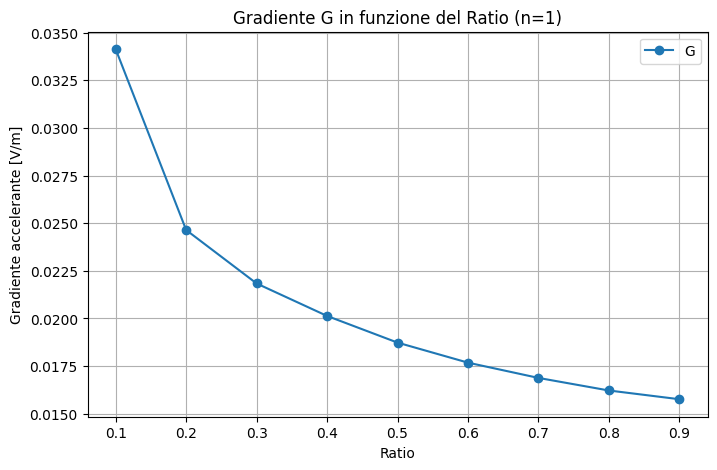

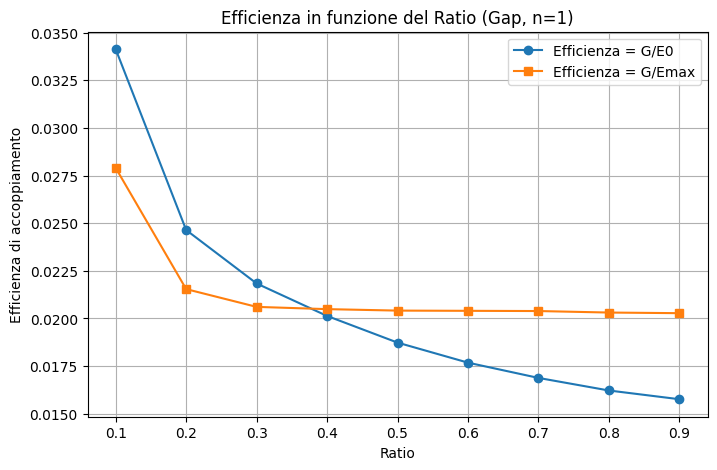

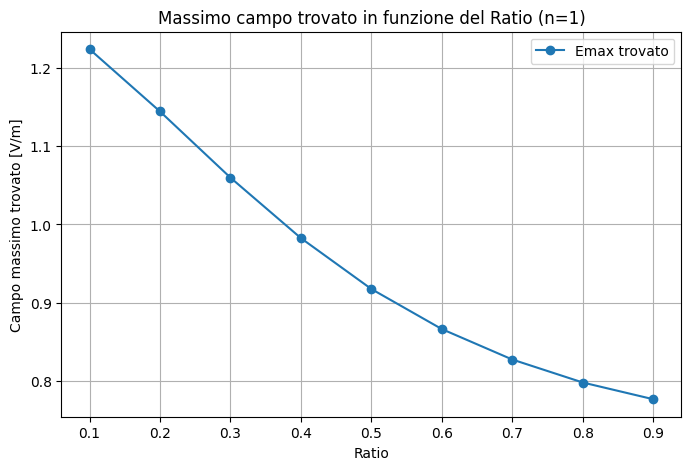

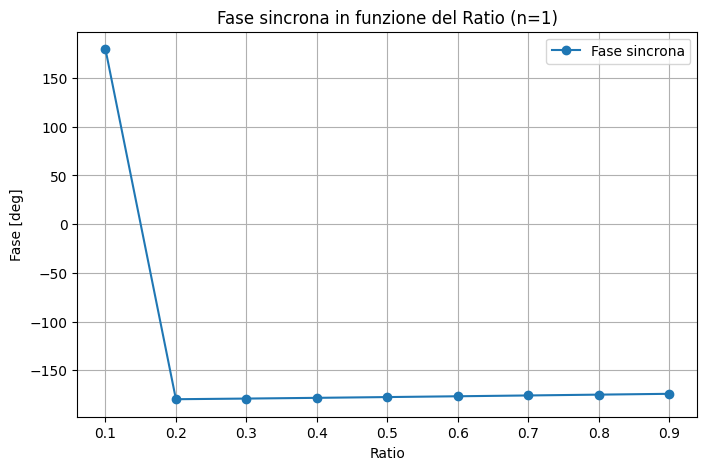

In [48]:
import re
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

cartella = Path("SIC_P_10um/n_1")
if not cartella.exists():
    raise FileNotFoundError(f"Cartella non trovata: {cartella.resolve()}")

# Parametri base (x e lambda_p sono in um)
beta = 0.01459
lambda_beta = 10 * beta  # periodo base
E0_const = 1.0  # V/m

im_blocks_by_n = parse_cst_block_file(cartella / "Gap_Im.txt")
re_blocks_by_n = parse_cst_block_file(cartella / "Gap_Real.txt")

available_n = sorted(set(im_blocks_by_n.keys()) & set(re_blocks_by_n.keys()))
if not available_n:
    raise ValueError("Nessun n in comune tra Gap_Im.txt e Gap_Real.txt")

print(f"Valori di n disponibili: {available_n}")

# Selezione n: metti un numero (es. 2) oppure lascia None per il primo disponibile
selected_n = 1
if selected_n is None:
    selected_n = available_n[0]

if selected_n not in available_n:
    raise ValueError(f"n={selected_n} non disponibile. Scegli tra: {available_n}")

im_blocks = im_blocks_by_n[selected_n]
re_blocks = re_blocks_by_n[selected_n]

common_ratios = sorted(set(im_blocks.keys()) & set(re_blocks.keys()))
if not common_ratios:
    raise ValueError(f"Nessun ratio in comune per n={selected_n} tra Gap_Im.txt e Gap_Real.txt")

n_harm = selected_n
lambda_p = n_harm * lambda_beta

G = np.zeros(len(common_ratios))
efficiency = np.zeros(len(common_ratios))
efficiency_max = np.zeros(len(common_ratios))
E_max_found = np.zeros(len(common_ratios))
phi_rad = np.zeros(len(common_ratios))
phi_deg = np.zeros(len(common_ratios))

for i, ratio_val in enumerate(common_ratios):
    x_im = im_blocks[ratio_val]["x"]
    x_re = re_blocks[ratio_val]["x"]
    im_ex = im_blocks[ratio_val]["y"]
    re_ex = re_blocks[ratio_val]["y"]

    if len(x_im) != len(x_re) or np.max(np.abs(x_im - x_re)) > 1e-12:
        raise ValueError(f"Asse x non allineato per n={selected_n}, ratio={ratio_val}")

    x = x_im
    Ex = re_ex + 1j * im_ex
    phase = np.exp(-1j * 2 * np.pi * n_harm * x / lambda_p)

    L = x[-1] - x[0]
    complex_grad = np.trapezoid(Ex * phase, x) / L

    G[i] = np.abs(complex_grad)
    phi_rad[i] = np.angle(complex_grad)
    phi_deg[i] = np.degrees(phi_rad[i])

    E_max_found[i] = np.max(np.abs(Ex))
    efficiency[i] = G[i] / E0_const
    efficiency_max[i] = G[i] / E_max_found[i]

    print(
        f"n={selected_n} ratio={ratio_val:.3f}  G={G[i]:.6e}  eta_E0={efficiency[i]:.6e}  "
        f"Emax={E_max_found[i]:.6e}  eta_Emax={efficiency_max[i]:.6e}  "
        f"phi={phi_rad[i]:+.4f} rad ({phi_deg[i]:+.2f} deg)"
        f"L={L:.6e} um"
    )

plt.figure(figsize=(8, 5))
plt.plot(common_ratios, G, marker="o", label="G")
plt.xlabel("Ratio")
plt.ylabel("Gradiente accelerante [V/m]")
plt.title(f"Gradiente G in funzione del Ratio (n={selected_n})")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(common_ratios, efficiency, marker="o", label="Efficienza = G/E0")
plt.plot(common_ratios, efficiency_max, marker="s", label="Efficienza = G/Emax")
plt.xlabel("Ratio")
plt.ylabel("Efficienza di accoppiamento")
plt.title(f"Efficienza in funzione del Ratio (Gap, n={selected_n})")
plt.grid(True)
plt.legend()
plt.savefig(cartella / f"Gap_efficiency_vs_ratio_n{selected_n}.png")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(common_ratios, E_max_found, marker="o", label="Emax trovato")
plt.xlabel("Ratio")
plt.ylabel("Campo massimo trovato [V/m]")
plt.title(f"Massimo campo trovato in funzione del Ratio (n={selected_n})")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(common_ratios, phi_deg, marker="o", label="Fase sincrona")
plt.xlabel("Ratio")
plt.ylabel("Fase [deg]")
plt.title(f"Fase sincrona in funzione del Ratio (n={selected_n})")
plt.grid(True)
plt.legend()
plt.show()

In [49]:
from pathlib import Path
import numpy as np


def read_cst_field_file(path):
    """Read CST field export: keep first 2 header lines and parse numeric table."""
    path = Path(path)

    with path.open("r", encoding="utf-8") as f:
        header1 = f.readline().rstrip("\n")
        header2 = f.readline().rstrip("\n")

    data = np.loadtxt(path, skiprows=2)
    if data.ndim == 1:
        data = data.reshape(1, -1)

    if data.shape[1] < 9:
        raise ValueError(f"{path.name}: attese almeno 9 colonne, trovate {data.shape[1]}")

    return header1, header2, data


def write_cst_field_file(path, header1, header2, data):
    """Write CST-like text file preserving header and numeric columns."""
    path = Path(path)

    with path.open("w", encoding="utf-8", newline="\n") as f:
        f.write(header1 + "\n")
        f.write(header2 + "\n")

        # 3 colonne coordinate + 6 colonne di campo
        for row in data:
            f.write(
                f"{row[0]:15.6f}"
                f"{row[1]:15.6f}"
                f"{row[2]:15.6f}"
                f"{row[3]:16.8e}"
                f"{row[4]:16.8e}"
                f"{row[5]:16.8e}"
                f"{row[6]:16.8e}"
                f"{row[7]:16.8e}"
                f"{row[8]:16.8e}\n"
            )


# File input: file1 e' il riferimento
file1 = Path("SIC_P_10um/n_3_bend/campo_3D.txt")
file2 = Path("SIC_P_10um/n_3_bend/campo_3D_alto.txt")
out_file = Path("SIC_P_10um/n_3_bend/Field_completo_somma.txt")

h1_1, h2_1, data1 = read_cst_field_file(file1)
h1_2, h2_2, data2 = read_cst_field_file(file2)

if data1.shape[1] < 9 or data2.shape[1] < 9:
    raise ValueError("Entrambi i file devono avere almeno 9 colonne (x y z + 6 componenti campo)")

# Coordinate come chiave esatta (nessuna tolleranza)
xyz1 = data1[:, :3]
xyz2 = data2[:, :3]
keys1 = [tuple(row) for row in xyz1]
keys2 = [tuple(row) for row in xyz2]

if len(set(keys1)) != len(keys1):
    raise ValueError(f"Coordinate duplicate in {file1.name}")
if len(set(keys2)) != len(keys2):
    raise ValueError(f"Coordinate duplicate in {file2.name}")

# Cerca in file2 le coordinate presenti in file1, indipendentemente dall'ordine
index2 = {k: i for i, k in enumerate(keys2)}
missing = [k for k in keys1 if k not in index2]
if missing:
    esempio = missing[0]
    raise ValueError(
        f"Coordinate mancanti in {file2.name}: {len(missing)} su {len(keys1)}. "
        f"Esempio mancante: x={esempio[0]}, y={esempio[1]}, z={esempio[2]}"
    )

aligned2_idx = [index2[k] for k in keys1]
aligned2 = data2[aligned2_idx]

# Somma componente per componente: ExRe ExIm EyRe EyIm EzRe EzIm (colonne 3:9)
out = data1.copy()
out[:, 3:9] = data1[:, 3:9] + aligned2[:, 3:9]

# Coordinate mantenute da file1 (riferimento)
out[:, :3] = data1[:, :3]

# Scrive con header del primo file
write_cst_field_file(out_file, h1_1, h2_1, out)

used_rows_file1 = len(out)
used_rows_file2 = len(set(aligned2_idx))
skipped_rows_file1 = len(data1) - used_rows_file1
skipped_rows_file2 = len(data2) - used_rows_file2

print(f"Creato: {out_file}")
print(f"Righe sommate: {len(out)}")
print(f"Righe extra in {file2.name} (ignorate): {len(data2) - len(data1)}")

if skipped_rows_file1 == 0 and skipped_rows_file2 == 0:
    print("Tutte le righe sono state usate in entrambi i file.")
else:
    print(
        "Attenzione: alcune righe non sono state usate -> "
        f"{file1.name}: {skipped_rows_file1}, {file2.name}: {skipped_rows_file2}"
    )

print("Prime 3 righe (x y z ExRe ExIm EyRe EyIm EzRe EzIm):")
print(out[:3, :9])

FileNotFoundError: [Errno 2] No such file or directory: 'SIC_P_10um\\n_3_bend\\campo_3D.txt'

In [ ]:
import re
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt


def parse_cst_block_file_by_param(path, param_name="H"):
    """Parse CST text export with repeated headers and return blocks keyed by param_name."""
    blocks = {}
    current_param = None
    current_x = []
    current_y = []

    pattern = re.compile(rf"{re.escape(param_name)}\s*=\s*([0-9]*\.?[0-9]+)")

    with open(path, "r", encoding="utf-8") as f:
        for raw_line in f:
            line = raw_line.strip()
            if not line:
                continue

            if line.startswith("#Parameters"):
                if current_param is not None and current_x:
                    blocks[current_param] = {
                        "x": np.array(current_x, dtype=float),
                        "y": np.array(current_y, dtype=float),
                    }

                m = pattern.search(line)
                if m is None:
                    current_param = None
                    current_x = []
                    current_y = []
                    continue

                current_param = float(m.group(1))
                current_x = []
                current_y = []
                continue

            if line.startswith("#"):
                continue

            if current_param is None:
                continue

            parts = line.split()
            if len(parts) < 2:
                continue

            try:
                x_val = float(parts[0])
                y_val = float(parts[1])
            except ValueError:
                continue

            current_x.append(x_val)
            current_y.append(y_val)

    if current_param is not None and current_x:
        blocks[current_param] = {
            "x": np.array(current_x, dtype=float),
            "y": np.array(current_y, dtype=float),
        }

    return blocks


cartella = Path("SIC_P_10um/n_3")
if not cartella.exists():
    raise FileNotFoundError(f"Cartella non trovata: {cartella.resolve()}")

# Parametri (x e lambda_p sono in um)
# Periodo della struttura in CST: periodo = n * lambda_beta
lambda_beta = 10 * 0.01459  # periodo base (145.9 nm)
n = 3
lambda_p = n * lambda_beta  # periodo EFFETTIVO in CST per questa armonica
E0_const = 1.0

im_blocks = parse_cst_block_file_by_param(cartella / "H_Im.txt", param_name="H")
re_blocks = parse_cst_block_file_by_param(cartella / "H_Real.txt", param_name="H")

common_H = sorted(set(im_blocks.keys()) & set(re_blocks.keys()))
if not common_H:
    raise ValueError("Nessun valore di H in comune tra H_Im.txt e H_Real.txt")

G = np.zeros(len(common_H))
efficiency = np.zeros(len(common_H))
efficiency_max = np.zeros(len(common_H))
E_max_found = np.zeros(len(common_H))
phi_rad = np.zeros(len(common_H))
phi_deg = np.zeros(len(common_H))

for i, h_val in enumerate(common_H):
    x_im = im_blocks[h_val]["x"]
    x_re = re_blocks[h_val]["x"]
    im_ex = im_blocks[h_val]["y"]
    re_ex = re_blocks[h_val]["y"]

    if len(x_im) != len(x_re) or np.max(np.abs(x_im - x_re)) > 1e-12:
        raise ValueError(f"Asse x non allineato per H={h_val}")

    x = x_im
    Ex = re_ex + 1j * im_ex
    phase = np.exp(-1j * 2 * np.pi * n * x / lambda_p)

    L = x[-1] - x[0]
    complex_grad = np.trapezoid(Ex * phase, x) / L

    G[i] = np.abs(complex_grad)
    phi_rad[i] = np.angle(complex_grad)
    phi_deg[i] = np.degrees(phi_rad[i])

    E_max_found[i] = np.max(np.abs(Ex))
    efficiency[i] = G[i] / E0_const
    efficiency_max[i] = G[i] / E_max_found[i]

    print(
        f"H={h_val:.6g}  G={G[i]:.6e}  eta_E0={efficiency[i]:.6e}  "
        f"Emax={E_max_found[i]:.6e}  eta_Emax={efficiency_max[i]:.6e}  "
        f"phi={phi_rad[i]:+.4f} rad ({phi_deg[i]:+.2f} deg)"
    )

plt.figure(figsize=(8, 5))
plt.plot(common_H, G, marker="o", label="G")
plt.xlabel("H")
plt.ylabel("Gradiente accelerante [V/m]")
plt.title("Gradiente G in funzione di H")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(common_H, efficiency, marker="o", label="Efficienza = G/E0")
plt.plot(common_H, efficiency_max, marker="s", label="Efficienza = G/Emax")
plt.xlabel("H")
plt.ylabel("Efficienza di accoppiamento")
plt.title("Efficienza in funzione di H")
plt.grid(True)
plt.legend()
plt.savefig(cartella / "H_efficiency_vs_H.png")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(common_H, E_max_found, marker="o", label="Emax trovato")
plt.xlabel("H")
plt.ylabel("Campo massimo trovato [V/m]")
plt.title("Massimo campo trovato in funzione di H")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(common_H, phi_deg, marker="o", label="Fase sincrona")
plt.xlabel("H")
plt.ylabel("Fase [deg]")
plt.title("Fase sincrona in funzione di H")
plt.grid(True)
plt.legend()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'SIC_P_10um\\n_3\\H_Im.txt'

Saltando 16 righe di header
Numero di protoni: 12488499, colonne: 12
Energia - min: 99.62 keV, max: 100.48 keV, media: 100.06 keV


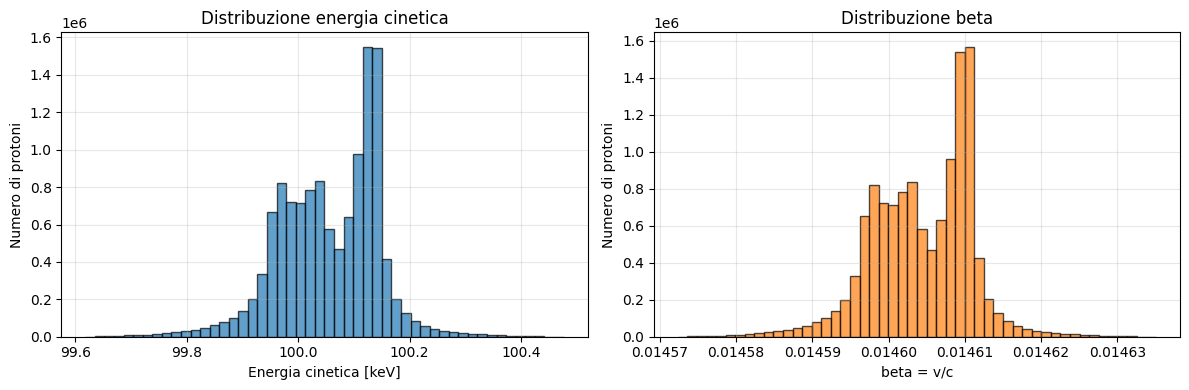

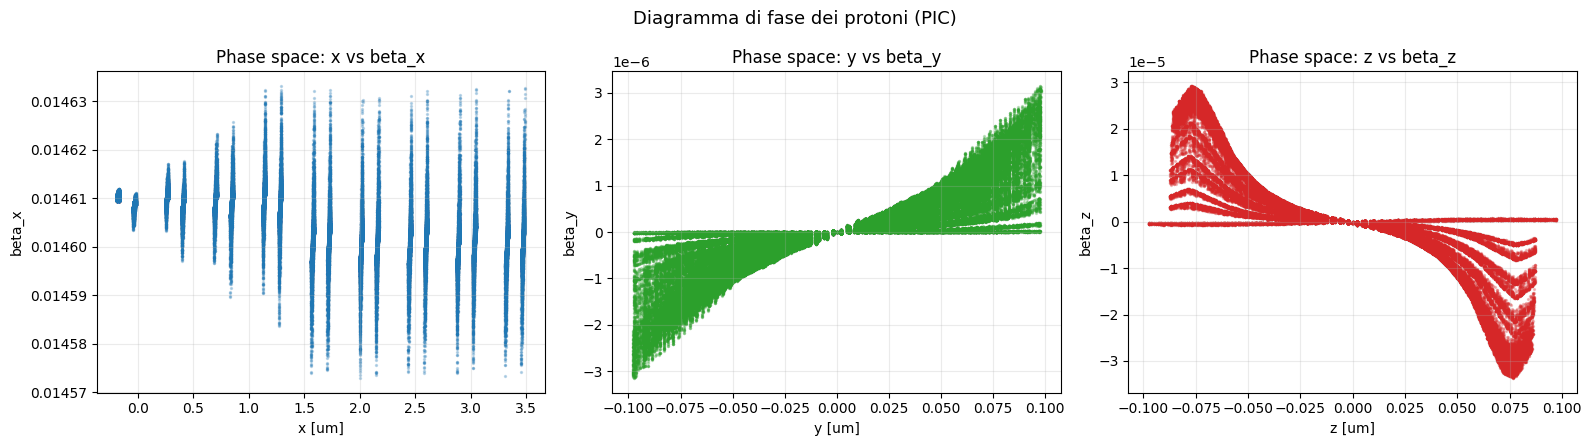

Protoni al piano x = 1.8 um: 692622


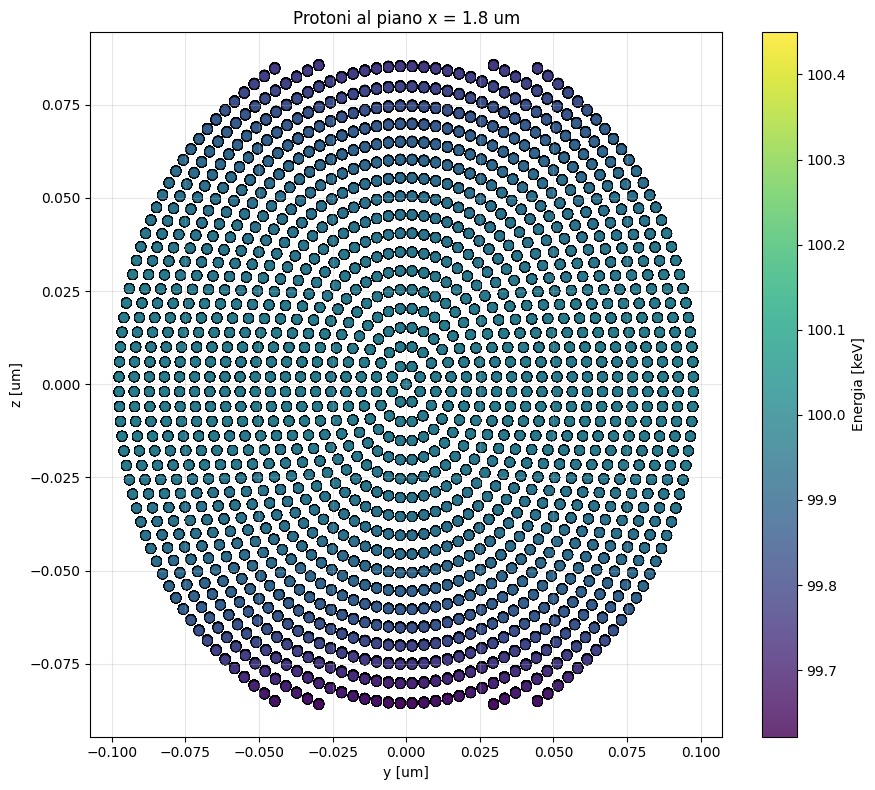

Heatmap: 792 bin non vuoti, energia varia da 99.81 a 100.23 keV


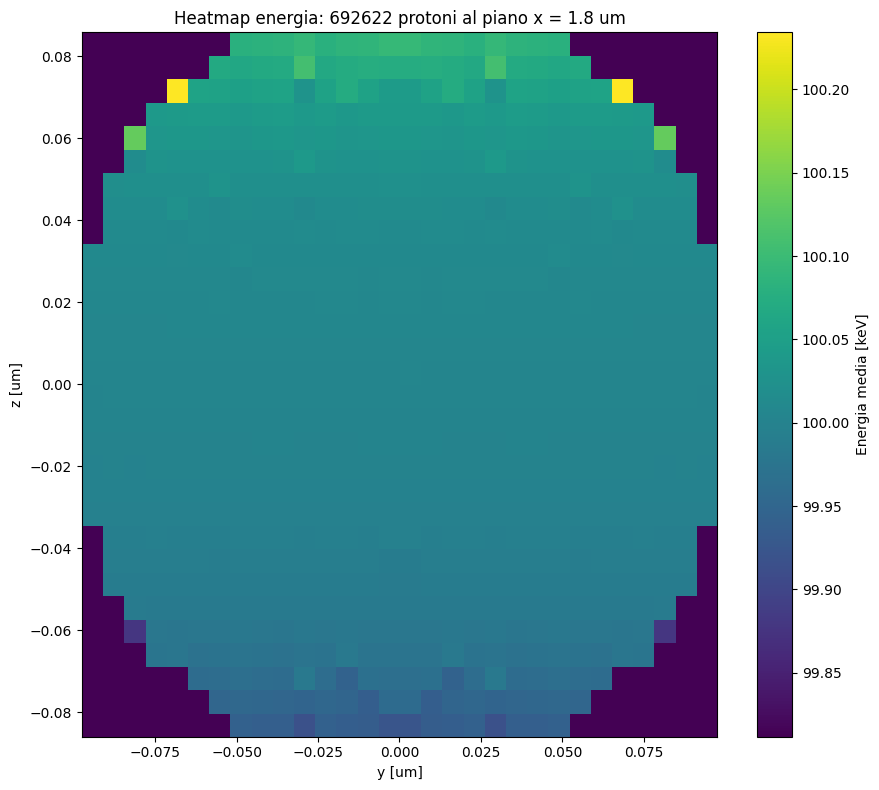

In [ ]:
# Analisi PIC (Particle In Cell): Energia e Heatmap finale
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pic_file = Path("SIC_P_10um/n_3/PIC2.txt")
if not pic_file.exists():
    raise FileNotFoundError(f"File non trovato: {pic_file.resolve()}")

# Leggi il file manualmente per rilevare header
with open(pic_file, "r") as f:
    lines = f.readlines()

header_lines = 0
for i, line in enumerate(lines):
    stripped = line.strip()
    if not stripped or stripped.startswith("%") or all(c == "-" for c in stripped):
        header_lines = i + 1
    else:
        try:
            float(stripped.split()[0])
            header_lines = i
            break
        except (ValueError, IndexError):
            header_lines = i + 1

print(f"Saltando {header_lines} righe di header")

# Carica dati
data = np.loadtxt(pic_file, skiprows=header_lines)
if data.ndim == 1:
    data = data.reshape(1, -1)

n_cols = data.shape[1]
print(f"Numero di protoni: {data.shape[0]}, colonne: {n_cols}")

x = data[:, 0]
y = data[:, 1]
z = data[:, 2]
px = data[:, 3]  # beta_x = v_x/c
py = data[:, 4]  # beta_y = v_y/c
pz = data[:, 5]  # beta_z = v_z/c

# Costanti
m_proton_MeV = 938.272  # MeV/c^2

# Energia cinetica: E_kin = mc^2 * (sqrt(1 + beta^2) - 1)
beta_mag = np.sqrt(px**2 + py**2 + pz**2)
gamma = np.sqrt(1 + beta_mag**2)
E_kin = m_proton_MeV * (gamma - 1)
E_kin_keV = E_kin * 1000

# Converti coordinate
x_um = x * 1e6
y_um = y * 1e6
z_um = z * 1e6

print(
    f"Energia - min: {E_kin_keV.min():.2f} keV, max: {E_kin_keV.max():.2f} keV, media: {E_kin_keV.mean():.2f} keV"
)

# Grafico 1: Distribuzione energia e beta
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(E_kin_keV, bins=50, color="tab:blue", edgecolor="black", alpha=0.7)
ax[0].set_xlabel("Energia cinetica [keV]")
ax[0].set_ylabel("Numero di protoni")
ax[0].set_title("Distribuzione energia cinetica")
ax[0].grid(True, alpha=0.3)

ax[1].hist(beta_mag, bins=50, color="tab:orange", edgecolor="black", alpha=0.7)
ax[1].set_xlabel("beta = v/c")
ax[1].set_ylabel("Numero di protoni")
ax[1].set_title("Distribuzione beta")
ax[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Grafico 2: Diagramma di fase (spazio delle fasi)
# Campionamento per rendere il plot piu leggibile con dataset grande
max_points = 120000
if len(x_um) > max_points:
    rng = np.random.default_rng(42)
    idx = rng.choice(len(x_um), size=max_points, replace=False)
else:
    idx = np.arange(len(x_um))

fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
ax[0].scatter(x_um[idx], px[idx], s=2, alpha=0.25, color="tab:blue")
ax[0].set_xlabel("x [um]")
ax[0].set_ylabel("beta_x")
ax[0].set_title("Phase space: x vs beta_x")
ax[0].grid(True, alpha=0.25)

ax[1].scatter(y_um[idx], py[idx], s=2, alpha=0.25, color="tab:green")
ax[1].set_xlabel("y [um]")
ax[1].set_ylabel("beta_y")
ax[1].set_title("Phase space: y vs beta_y")
ax[1].grid(True, alpha=0.25)

ax[2].scatter(z_um[idx], pz[idx], s=2, alpha=0.25, color="tab:red")
ax[2].set_xlabel("z [um]")
ax[2].set_ylabel("beta_z")
ax[2].set_title("Phase space: z vs beta_z")
ax[2].grid(True, alpha=0.25)

fig.suptitle("Diagramma di fase dei protoni (PIC)", fontsize=13)
plt.tight_layout()
plt.show()

# Seleziona protoni al piano x = 1.8 um
x_plane = 1.8
x_tol = 0.15
mask_plane = np.abs(x_um - x_plane) < x_tol
y_plane = y_um[mask_plane]
z_plane = z_um[mask_plane]
E_plane = E_kin_keV[mask_plane]

print(f"Protoni al piano x = {x_plane} um: {mask_plane.sum()}")

if mask_plane.sum() > 0:
    # Scatter plot
    fig, ax = plt.subplots(figsize=(9, 8))
    scatter = ax.scatter(
        y_plane,
        z_plane,
        c=E_plane,
        s=50,
        cmap="viridis",
        edgecolors="black",
        linewidth=0.5,
        alpha=0.8,
    )
    ax.set_xlabel("y [um]")
    ax.set_ylabel("z [um]")
    ax.set_title(f"Protoni al piano x = {x_plane} um")
    ax.grid(True, alpha=0.3)
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label("Energia [keV]")
    plt.tight_layout()
    plt.show()

    # Heatmap 2D
    fig, ax = plt.subplots(figsize=(9, 8))

    y_min, y_max = y_plane.min(), y_plane.max()
    z_min, z_max = z_plane.min(), z_plane.max()
    n_bins = 30

    heatmap, yedges, zedges = np.histogram2d(y_plane, z_plane, bins=n_bins, weights=E_plane)
    counts, _, _ = np.histogram2d(y_plane, z_plane, bins=n_bins)

    heatmap_avg = np.divide(heatmap, counts, where=(counts > 0), out=np.zeros_like(heatmap))

    # Info debug
    valid_vals = heatmap_avg[heatmap_avg > 0]
    print(
        f"Heatmap: {len(valid_vals)} bin non vuoti, energia varia da {valid_vals.min():.2f} a {valid_vals.max():.2f} keV"
    )

    # Visualizza con range effettivo
    vmin_val = valid_vals.min()
    vmax_val = valid_vals.max()

    im = ax.imshow(
        heatmap_avg.T,
        origin="lower",
        aspect="auto",
        cmap="viridis",
        extent=[y_min, y_max, z_min, z_max],
        vmin=vmin_val,
        vmax=vmax_val,
    )

    ax.set_xlabel("y [um]")
    ax.set_ylabel("z [um]")
    ax.set_title(f"Heatmap energia: {mask_plane.sum()} protoni al piano x = {x_plane} um")

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Energia media [keV]")

    plt.tight_layout()
    plt.show()
else:
    print(f"Nessun protone trovato al piano x = {x_plane} um!")

Range x: [-0.187, 3.489] um
Range energia: [99.618, 100.477] keV


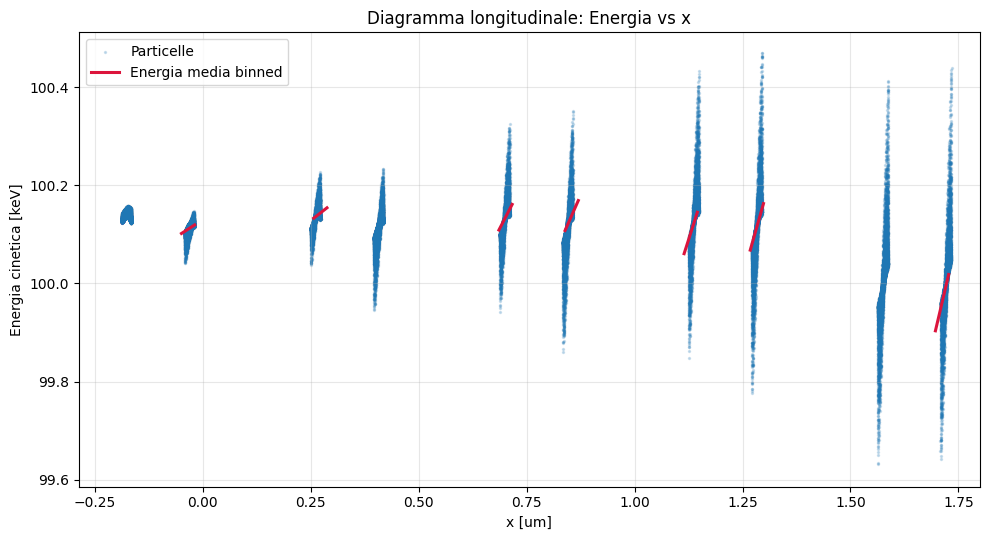

In [ ]:
# Grafico aggiuntivo: energia cinetica vs posizione x
# Richiede che la cella PIC (cella 8) sia gia stata eseguita
if "x_um" not in globals() or "E_kin_keV" not in globals():
    raise RuntimeError("Esegui prima la cella 8 (analisi PIC) per creare x_um ed E_kin_keV")

fig, ax = plt.subplots(figsize=(10, 5.5))

# Scatter sottocampionato per leggibilita
max_points = 150000
if len(x_um) > max_points:
    rng = np.random.default_rng(7)
    idx = rng.choice(len(x_um), size=max_points, replace=False)
else:
    idx = np.arange(len(x_um))

ax.scatter(x_um[idx], E_kin_keV[idx], s=2, alpha=0.2, color="tab:blue", label="Particelle")

# Curva media binned E(x)
n_bins_x = 120
sum_E, x_edges = np.histogram(x_um, bins=n_bins_x, weights=E_kin_keV)
count_E, _ = np.histogram(x_um, bins=n_bins_x)
mean_E = np.divide(sum_E, count_E, out=np.full_like(sum_E, np.nan, dtype=float), where=(count_E > 0))
x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])

ax.plot(x_centers, mean_E, color="crimson", lw=2.2, label="Energia media binned")

ax.set_xlabel("x [um]")
ax.set_ylabel("Energia cinetica [keV]")
ax.set_title("Diagramma longitudinale: Energia vs x")
ax.grid(True, alpha=0.3)
ax.set_xlim(x_um.min() - 0.1, 1.8)
ax.legend()

print(f"Range x: [{x_um.min():.3f}, {x_um.max():.3f}] um")
print(f"Range energia: [{E_kin_keV.min():.3f}, {E_kin_keV.max():.3f}] keV")

plt.tight_layout()
plt.show()